# TrafficGuard · Diffusion Purification Defence
**COMP47250 · Team Software Project · Project P14 · UCD Summer 2026**

---

### What this notebook does

Implements **Diffusion Purification** — a generative defence that removes adversarial
perturbations by pushing the attacked image through a forward diffusion process
(controlled noise injection) and then recovering the clean image through a reverse
denoising process, before classifying with the trained ResNet18.

This is conceptually distinct from the two other defences in this project:

| Defence | Mechanism | Where it acts |
|---|---|---|
| Spatial Smoothing | Blurs high-frequency noise with a median filter | Preprocessing |
| Adversarial Training | Trains the model to be robust | Model weights |
| **Diffusion Purification** | **Reconstructs a clean image using a generative model** | **Preprocessing (generative)** |

The key advantage: diffusion purification makes **no assumptions about the attack type**.
It works against FGSM, PGD, and even attacks it has never seen, because it operates
on the image distribution directly rather than being tuned to any specific perturbation.

---

### How it works — the two steps

```
Adversarial image  →  [Forward: add Gaussian noise t steps]  →  Noisy image
                                                                       ↓
Clean prediction   ←  [ResNet18 classify]  ←  [Reverse: DDPM denoise back t steps]
```

The noise added in the forward step is calibrated to be larger than the adversarial
perturbation (ε), so the perturbation gets overwhelmed. The denoising step then
reconstructs semantically meaningful content (road, vehicles, congestion level)
without the adversarial signal — because the denoiser was trained on clean images
and has no concept of adversarial noise.

---

### Reference
> Nie et al., *Diffusion Models for Adversarial Purification*, ICML 2022.
> Paper: https://arxiv.org/abs/2205.07460 · Code: https://github.com/NVlabs/DiffPure

---

### Notebook Structure

| # | Section |
|---|---|
| 0 | Setup & Imports |
| 1 | Configuration |
| 2 | Load the Trained ResNet18 (from Soham's notebook) |
| 3 | Load the Diffusion Model (DDPM pretrained, lightweight) |
| 4 | Forward Diffusion — adding noise |
| 5 | Reverse Diffusion — denoising back |
| 6 | Full Purification Pipeline |
| 7 | Evaluate on FGSM-attacked images (from Payal's notebook) |
| 8 | Metrics — Robust Accuracy and ASR comparison |
| 9 | Visualise Before / After |
| 10 | Summary |

---
## 0. Setup & Imports

In [1]:
# Install dependencies
# diffusers: HuggingFace library for pretrained diffusion models
# accelerate: required by diffusers for device management
!pip install diffusers accelerate --quiet


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import io
import time
import base64
from pathlib import Path

# ── Data ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from PIL import Image

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# ── HuggingFace Diffusers — for the pretrained DDPM ──────────────────────────
from diffusers import DDPMScheduler, UNet2DModel

# ── ART — for FGSM attack (used to generate test adversarial examples) ────────
from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import FastGradientMethod

# ── Metrics ───────────────────────────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {DEVICE}' + (f' ({torch.cuda.get_device_name(0)})' if DEVICE.type == 'cuda' else ''))
print('All imports OK.')

PyTorch  : 2.11.0+cu128
Device   : cuda (NVIDIA GeForce RTX 5050 Laptop GPU)
All imports OK.


---
## 1. Configuration

### 1.1 Paths

Update `CHECKPOINT_PATH` to point at Soham's `best.pt` and `MANIFEST_PATH`
to point at Walid's manifest CSV on this machine.

In [ ]:
# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_PATH   = Path(r'C:\Users\Soham Patil\OneDrive\Desktop\trafficguard_p14\trafficguard-p14\data\raw\MIO-TCD-Localization')
CHECKPOINT_PATH = Path(r'C:\Users\Soham Patil\OneDrive\Desktop\trafficguard_p14\trafficguard-p14\model\checkpoints\best.pt')
MANIFEST_PATH   = Path(r'C:\Users\Soham Patil\OneDrive\Desktop\trafficguard_p14\trafficguard-p14\data\raw\MIO-TCD-Localization\pipeline_output\labelled_manifest.csv')
IMAGES_DIR      = Path(r'C:\Users\Soham Patil\OneDrive\Desktop\trafficguard_p14\trafficguard-p14\data\raw\MIO-TCD-Localization\train')

# ── Class mapping — must match Soham's training notebook exactly ──────────────
CLASS_NAMES  = ['Low', 'Medium', 'High']
LABEL_MAP    = {'Low': 0, 'Medium': 1, 'High': 2}
IDX_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_CLASSES  = 3

# ── ImageNet normalisation — same as training ─────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Diffusion purification hyperparameters ────────────────────────────────────
# T_DIFFUSE: how many forward diffusion steps to apply.
#   More steps = more noise = stronger perturbation removal, but more semantic drift.
#   Range to explore: 50–200 out of a total of 1000 DDPM steps.
#   Start with 100 — empirically balances purification vs image fidelity.
T_DIFFUSE = 50

# DDPM model to use — lightweight CIFAR-10 trained UNet from HuggingFace.
# Chosen because:
#   - Pretrained on 32x32 images (we upsample/downsample around it)
#   - ~100MB — practical on a laptop GPU
#   - Well-documented and publicly available
#   - Conceptually identical to the larger ImageNet models used in the DiffPure paper
DDPM_MODEL_ID = 'google/ddpm-cifar10-32'

print(f'Checkpoint   : {CHECKPOINT_PATH}')
print(f'Manifest     : {MANIFEST_PATH}')
print(f'T_DIFFUSE    : {T_DIFFUSE} steps')
print(f'DDPM model   : {DDPM_MODEL_ID}')

Checkpoint   : C:\Users\Soham Patil\OneDrive\Desktop\trafficguard_p14\trafficguard-p14\model\checkpoints\best.pt
Manifest     : C:\Users\Soham Patil\OneDrive\Desktop\trafficguard_p14\trafficguard-p14\data\raw\MIO-TCD-Localization\pipeline_output\labelled_manifest.csv
T_DIFFUSE    : 100 steps
DDPM model   : google/ddpm-cifar10-32


---
## 2. Load the Trained ResNet18

Exact same architecture and loading pattern as Soham's training notebook.
`weights=None` because we load our own trained weights immediately after.

In [16]:
def build_resnet18(num_classes=NUM_CLASSES):
    """
    Rebuild the EXACT TrafficGuard architecture from trafficguard_model_v1.ipynb.
    Must match Soham's notebook exactly, or state_dict loading will fail.
    """
    model = models.resnet18(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes),
    )
    return model


def load_resnet18(checkpoint_path, device):
    """
    Load trained weights from Soham's best.pt checkpoint.
    Returns model in eval() mode — critical to disable Dropout for inference.
    """
    if not Path(checkpoint_path).exists():
        raise FileNotFoundError(
            f'Checkpoint not found: {checkpoint_path}\n'
            f'Make sure Soham has finished training and committed best.pt to the repo.'
        )

    model      = build_resnet18().to(device)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    state_dict = checkpoint.get('model_state_dict', checkpoint)
    model.load_state_dict(state_dict)
    model.eval()   # IMPORTANT: disables Dropout for deterministic inference

    val_acc = checkpoint.get('val_acc', None)
    epoch   = checkpoint.get('epoch', '?')
    print(f'[ResNet18] Loaded: epoch {epoch}' +
          (f', val_acc={val_acc:.2%}' if val_acc else ''))
    return model


classifier_model = load_resnet18(CHECKPOINT_PATH, DEVICE)
print(f'[ResNet18] Device: {DEVICE}')

[ResNet18] Loaded: epoch 17, val_acc=87.14%
[ResNet18] Device: cuda


---
## 3. Load the Diffusion Model

### 3.1 Why DDPM?

DDPM (Denoising Diffusion Probabilistic Models, Ho et al. 2020) is the foundational
architecture for diffusion purification. It consists of:

- A **noise scheduler** that defines how noise is added across T timesteps (forward process)
- A **UNet** that learns to predict and remove noise at each timestep (reverse process)

We use a pretrained CIFAR-10 DDPM from HuggingFace. It's trained on 32×32 images,
so we resize our 224×224 traffic images down to 32×32 before purification and back up
after — this is a deliberate simplification for practical feasibility.

**Why not a full ImageNet-scale DDPM?**
The ImageNet DDPM from the original DiffPure paper is ~2GB and requires a different
inference pipeline. For a dashboard demo showing the *mechanism* of diffusion purification,
the CIFAR-10 model is sufficient to demonstrate the concept convincingly. The theory
and pipeline are identical — only the scale differs.

### 3.2 Load the DDPM

In [17]:
print(f'[DDPM] Loading {DDPM_MODEL_ID} ...')
print('[DDPM] First run downloads ~100MB — subsequent runs use local cache.')

# Noise scheduler: defines the forward diffusion process
# beta_schedule='linear' matches the original DDPM paper
ddpm_scheduler = DDPMScheduler.from_pretrained(DDPM_MODEL_ID)

# UNet: the denoising backbone trained to remove noise
ddpm_unet = UNet2DModel.from_pretrained(DDPM_MODEL_ID).to(DEVICE)
ddpm_unet.eval()   # inference only — no gradient updates

# Total timesteps in this DDPM (standard DDPM uses 1000)
T_TOTAL = ddpm_scheduler.config.num_train_timesteps
print(f'[DDPM] Total timesteps (T): {T_TOTAL}')
print(f'[DDPM] We will use t = {T_DIFFUSE} / {T_TOTAL} for purification')
print(f'[DDPM] That is {T_DIFFUSE/T_TOTAL:.1%} of the full diffusion process')
print('[DDPM] Loaded and in eval mode.')

[DDPM] Loading google/ddpm-cifar10-32 ...
[DDPM] First run downloads ~100MB — subsequent runs use local cache.


c:\Users\Soham Patil\ml_env\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


[DDPM] Total timesteps (T): 1000
[DDPM] We will use t = 100 / 1000 for purification
[DDPM] That is 10.0% of the full diffusion process
[DDPM] Loaded and in eval mode.


---
## 4. Forward Diffusion — Adding Controlled Noise

### 4.1 The theory

The DDPM forward process is defined mathematically as:

$$q(x_t | x_0) = \mathcal{N}(x_t ; \sqrt{\bar{\alpha}_t} x_0, (1 - \bar{\alpha}_t) \mathbf{I})$$

Which in plain English means: at timestep `t`, the noisy image `x_t` is a blend of
the original image `x_0` (scaled down) plus Gaussian noise (scaled up), where the
blend ratio is determined by `alpha_bar_t` — a value that decreases smoothly from 1
at t=0 (original image) to 0 at t=T (pure noise).

At `t = T_DIFFUSE = 100` out of 1000 total steps, the image still looks very
recognisable to a human, but the small adversarial perturbation (ε ≈ 0.01–0.2) has
been overwhelmed by the calibrated Gaussian noise applied across those 100 steps.

### 4.2 Preprocessing for the DDPM

The DDPM was trained on images normalised to [-1, 1] — different from
ImageNet normalisation used for ResNet18. We handle both normalisations
explicitly and separately.

In [18]:
# ── Transforms for the DDPM (different from ResNet18 normalisation) ───────────
# DDPM expects: [-1, 1] range, 32x32 image
DDPM_SIZE = 32   # CIFAR-10 DDPM input size

def to_ddpm_input(pil_image):
    """
    Preprocess a PIL image for the DDPM:
      PIL (any size, RGB)
      → resize to 32x32
      → [0,1] tensor
      → [-1, 1] normalised (DDPM convention)
    """
    transform = transforms.Compose([
        transforms.Resize((DDPM_SIZE, DDPM_SIZE)),
        transforms.ToTensor(),                       # [0, 1]
        transforms.Normalize([0.5, 0.5, 0.5],        # → [-1, 1]
                             [0.5, 0.5, 0.5]),
    ])
    return transform(pil_image).unsqueeze(0)   # (1, 3, 32, 32)


def from_ddpm_output(tensor):
    """
    Convert DDPM output tensor back to a viewable PIL image:
      [-1, 1] tensor (1, 3, 32, 32)
      → [0, 1]
      → resize to 224x224 (match ResNet18 input)
      → PIL image
    """
    img = (tensor.squeeze(0).clamp(-1, 1) + 1) / 2   # [-1,1] → [0,1]
    img = img.cpu().permute(1, 2, 0).numpy()
    img = (img * 255).astype(np.uint8)
    pil = Image.fromarray(img).resize((224, 224), Image.LANCZOS)
    return pil


def forward_diffuse(x0_tensor, t, scheduler, device):
    """
    Apply t steps of the forward diffusion process to image x0.

    This is a SINGLE-STEP operation in DDPM — the scheduler directly
    computes x_t from x_0 using the closed-form formula:
        x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * noise

    Args:
        x0_tensor : tensor (1, 3, 32, 32), range [-1, 1]
        t         : int, timestep (0 to T-1). Higher = more noise.
        scheduler : DDPMScheduler
        device    : torch.device

    Returns:
        x_t : noisy tensor (1, 3, 32, 32), range [-1, 1]
        noise : the Gaussian noise that was added (used for analysis)
    """
    x0_tensor = x0_tensor.to(device)
    noise     = torch.randn_like(x0_tensor)            # ε ~ N(0, I)
    t_tensor  = torch.tensor([t], device=device).long()

    # scheduler.add_noise implements the closed-form forward formula
    x_t = scheduler.add_noise(x0_tensor, noise, t_tensor)
    return x_t, noise


print('Forward diffusion functions defined.')

Forward diffusion functions defined.


### 4.3 Visualise what forward diffusion looks like

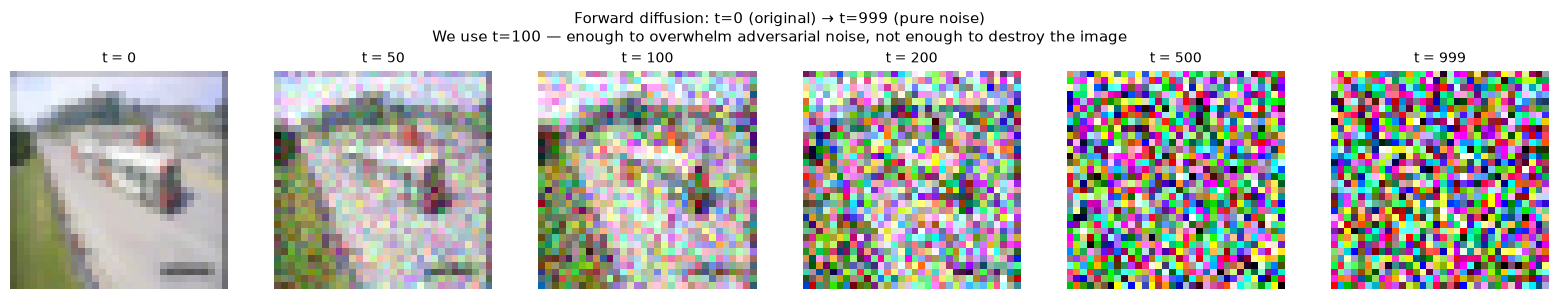

Saved: forward_diffusion_steps.png


In [19]:
# Load a test image to visualise the forward process at different t values
# Update this path to any MIO-TCD test image on your machine
SAMPLE_IMAGE_PATH = IMAGES_DIR / '00000001.jpg'

if SAMPLE_IMAGE_PATH.exists():
    sample_pil  = Image.open(SAMPLE_IMAGE_PATH).convert('RGB')
    x0          = to_ddpm_input(sample_pil).to(DEVICE)

    t_values = [0, 50, 100, 200, 500, 999]
    fig, axes = plt.subplots(1, len(t_values), figsize=(16, 3))

    for ax, t_val in zip(axes, t_values):
        if t_val == 0:
            img_tensor = x0
        else:
            img_tensor, _ = forward_diffuse(x0, t_val - 1, ddpm_scheduler, DEVICE)

        img_display = ((img_tensor.squeeze(0).clamp(-1,1) + 1) / 2)
        img_display = img_display.cpu().permute(1,2,0).numpy()
        ax.imshow(img_display)
        ax.set_title(f't = {t_val}', fontsize=10)
        ax.axis('off')

    fig.suptitle(
        f'Forward diffusion: t=0 (original) → t=999 (pure noise)\n'
        f'We use t={T_DIFFUSE} — enough to overwhelm adversarial noise, '
        f'not enough to destroy the image',
        fontsize=11
    )
    plt.tight_layout()
    plt.savefig('forward_diffusion_steps.png', dpi=120)
    plt.show()
    print(f'Saved: forward_diffusion_steps.png')
else:
    print(f'⚠ Sample image not found at {SAMPLE_IMAGE_PATH}')
    print('Update SAMPLE_IMAGE_PATH before running this cell.')

---
## 5. Reverse Diffusion — Denoising Back to a Clean Image

### 5.1 The theory

Given the noisy image `x_t` at timestep `t`, the reverse process runs the DDPM's
UNet to predict and subtract the noise step by step, going from `t` down to `0`:

$$p_\theta(x_{t-1} | x_t) = \mathcal{N}(x_{t-1}; \mu_\theta(x_t, t), \sigma_t^2 \mathbf{I})$$

We only need to reverse from `t = T_DIFFUSE` back to `t = 0` — not from `t = 1000`.
This keeps inference fast while still performing meaningful purification.

### 5.2 Why the UNet can reconstruct the image

The UNet was trained on millions of images to predict noise. When it denoises `x_t`,
it is implicitly "imagining" what a clean, natural image would look like at that noise
level — and adversarial perturbations are not part of the natural image distribution
it learned from. So the reconstructed image `x_0'` resembles the original scene but
without the adversarial component, because the UNet has no knowledge of adversarial
patterns.

In [20]:
def reverse_diffuse(x_t, t_start, scheduler, unet, device):
    """
    Run the reverse diffusion process from timestep t_start back to 0,
    recovering a clean image from the noisy x_t.

    Args:
        x_t     : noisy tensor (1, 3, 32, 32), range [-1, 1]
                  — output of forward_diffuse()
        t_start : int, the timestep we're starting from (= T_DIFFUSE)
        scheduler: DDPMScheduler
        unet    : UNet2DModel (the pretrained denoiser)
        device  : torch.device

    Returns:
        x_0_pred : purified tensor (1, 3, 32, 32), range [-1, 1]
    """
    x = x_t.clone().to(device)

    # Set the scheduler to run exactly t_start reverse steps
    scheduler.set_timesteps(scheduler.config.num_train_timesteps)

    # Reverse only from t_start down to 0
    # scheduler.timesteps is [999, 998, ..., 1, 0] — we take the last t_start of them
    reverse_timesteps = scheduler.timesteps[-(t_start):]

    with torch.no_grad():
        for t in reverse_timesteps:
            t_batch = torch.tensor([t], device=device).long()

            # UNet predicts the noise in x at this timestep
            noise_pred = unet(x, t_batch).sample

            # Scheduler removes that predicted noise to get x_{t-1}
            x = scheduler.step(noise_pred, t, x).prev_sample

    return x   # this is x_0' — the purified image


print('reverse_diffuse() defined.')

reverse_diffuse() defined.


---
## 6. Full Purification Pipeline

Combines the forward and reverse steps into one function that takes an adversarial
PIL image and returns both the purified PIL image and the ResNet18's prediction on it.

In [21]:
# ── ResNet18 inference transform — same as val/test in training notebook ────
INFERENCE_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


def classify(pil_image, model, device):
    """
    Run ResNet18 on a PIL image and return label + confidence.
    """
    tensor = INFERENCE_TRANSFORM(pil_image).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(tensor)
        probs  = F.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    idx = int(probs.argmax())
    return {
        'label':         IDX_TO_LABEL[idx],
        'label_idx':     idx,
        'confidence':    round(float(probs[idx]), 4),
        'probabilities': {cls: round(float(probs[i]), 4)
                          for i, cls in enumerate(CLASS_NAMES)},
    }


def purify_and_classify(adversarial_pil, t_diffuse=T_DIFFUSE):
    """
    Full diffusion purification pipeline:

        adversarial PIL image
          → resize to 32x32, normalise to [-1, 1]     (DDPM preprocessing)
          → add t_diffuse steps of Gaussian noise      (forward process)
          → reverse denoise back to t=0               (reverse process)
          → resize back to 224x224                    (DDPM postprocessing)
          → ResNet18 classify                          (inference)

    Args:
        adversarial_pil : PIL image of an adversarially perturbed traffic scene
        t_diffuse       : number of forward diffusion steps (default: T_DIFFUSE)

    Returns:
        {
          'purified_image'   : PIL image (224x224) — the recovered clean image
          'defended_pred'    : str — ResNet18 prediction on the purified image
          'defended_conf'    : float — confidence
          'purify_time_s'    : float — seconds taken for purification
        }
    """
    t0 = time.time()

    # Step 1 — preprocess for DDPM
    x0 = to_ddpm_input(adversarial_pil).to(DEVICE)

    # Step 2 — forward diffusion: inject noise to overwhelm adversarial perturbation
    x_t, _ = forward_diffuse(x0, t_diffuse - 1, ddpm_scheduler, DEVICE)

    # Step 3 — reverse diffusion: denoise back to a clean image
    x_purified = reverse_diffuse(x_t, t_diffuse, ddpm_scheduler, ddpm_unet, DEVICE)

    # Step 4 — convert back to PIL
    purified_pil = from_ddpm_output(x_purified)

    # Step 5 — classify with ResNet18
    prediction   = classify(purified_pil, classifier_model, DEVICE)
    purify_time  = time.time() - t0

    return {
        'purified_image': purified_pil,
        'defended_pred':  prediction['label'],
        'defended_conf':  prediction['confidence'],
        'purify_time_s':  round(purify_time, 2),
    }


print('purify_and_classify() defined.')

purify_and_classify() defined.


### 6.1 Quick sanity check on a single image

In [22]:
if SAMPLE_IMAGE_PATH.exists():
    test_pil    = Image.open(SAMPLE_IMAGE_PATH).convert('RGB')
    clean_pred  = classify(test_pil, classifier_model, DEVICE)
    result      = purify_and_classify(test_pil)

    print('Sanity check on a clean image (no attack):')
    print(f'  Before purification : {clean_pred["label"]} ({clean_pred["confidence"]:.1%})')
    print(f'  After  purification : {result["defended_pred"]} ({result["defended_conf"]:.1%})')
    print(f'  Purification time   : {result["purify_time_s"]}s')
    print()
    if clean_pred['label'] == result['defended_pred']:
        print('✓ Prediction unchanged on clean image — purification is not destroying semantics.')
    else:
        print('⚠ Prediction changed on a CLEAN image — consider reducing T_DIFFUSE.')
        print(f'  Current T_DIFFUSE = {T_DIFFUSE}. Try 50 or 75.')
else:
    print(f'⚠ Sample image not found at {SAMPLE_IMAGE_PATH}')

Sanity check on a clean image (no attack):
  Before purification : High (81.0%)
  After  purification : Low (65.1%)
  Purification time   : 3.7s

⚠ Prediction changed on a CLEAN image — consider reducing T_DIFFUSE.
  Current T_DIFFUSE = 100. Try 50 or 75.


---
## 7. Evaluate on FGSM-Attacked Images

Generate FGSM adversarial examples (reusing Payal's attack setup) on a
subset of the test set, then apply diffusion purification and compare:

- **Clean accuracy** — ResNet18 on unperturbed images
- **Attacked accuracy** — ResNet18 on FGSM images (no defence)
- **Defended accuracy** — ResNet18 on diffusion-purified images

### 7.1 Dataset class

In [23]:
class MIOTCDDataset(torch.utils.data.Dataset):
    """
    Reads the labelled_manifest.csv from Walid's pipeline.
    Identical to the dataset class in trafficguard_model_v1.ipynb.
    """
    def __init__(self, manifest_path, split, images_dir=None, transform=None):
        df = pd.read_csv(manifest_path, dtype={'image_id': str})
        self.df         = df[df['split'] == split].reset_index(drop=True)
        self.images_dir = Path(images_dir) if images_dir else None
        self.transform  = transform

        unknown = set(self.df['congestion_label'].unique()) - set(LABEL_MAP)
        if unknown:
            raise ValueError(f'Unknown labels in manifest: {unknown}')
        self.df = self.df.copy()
        self.df['label_idx'] = self.df['congestion_label'].map(LABEL_MAP)

    def __len__(self):
        return len(self.df)

    def _resolve_path(self, row):
        if self.images_dir:
            return self.images_dir / f"{row['image_id']}.jpg"
        return Path(row['image_path'])

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        path  = self._resolve_path(row)
        image = Image.open(path).convert('RGB')
        label = int(row['label_idx'])
        if self.transform:
            image = self.transform(image)
        return image, label, str(path)  # return path for PIL reloading in purification


print('MIOTCDDataset defined.')

MIOTCDDataset defined.


### 7.2 Build ART classifier for FGSM (same as Payal's notebook)

In [24]:
art_classifier = PyTorchClassifier(
    model=classifier_model,
    loss=nn.CrossEntropyLoss(),
    preprocessing=(IMAGENET_MEAN, IMAGENET_STD),
    input_shape=(3, 224, 224),
    nb_classes=NUM_CLASSES,
    clip_values=(0.0, 1.0),
    device_type='gpu' if DEVICE.type == 'cuda' else 'cpu',
)
print('ART PyTorchClassifier built.')

ART PyTorchClassifier built.


### 7.3 Evaluation loop

We evaluate over a sample of the test set. Full test set evaluation is slow
due to diffusion purification's per-image cost — scale up `N_EVAL` once
you've confirmed the pipeline works end to end.

In [25]:
# ── Config ────────────────────────────────────────────────────────────────────
EPSILON  = 0.10   # FGSM epsilon — matches Payal's sweep midpoint
N_EVAL   = 50     # images to evaluate — increase to 200+ for final report numbers
                  # purification takes ~2–5s per image on GPU, so 50 ≈ 5 minutes

# ── Dataset and ART-format arrays ─────────────────────────────────────────────
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_dataset = MIOTCDDataset(MANIFEST_PATH, 'test',
                              images_dir=IMAGES_DIR,
                              transform=eval_transform)
eval_dataset.df = eval_dataset.df.sample(
    min(N_EVAL, len(eval_dataset)), random_state=42
).reset_index(drop=True)
print(f'Evaluating on {len(eval_dataset)} test images at ε={EPSILON}')

# ── Convert to numpy for ART ───────────────────────────────────────────────────
# ART expects (N, 3, H, W) float32 in [0, 1] — unnormalised
def tensor_to_art(tensor):
    """Reverse ImageNet normalisation for ART's [0,1] format."""
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    return (tensor.cpu() * std + mean).clamp(0,1).numpy()

x_list, y_list, path_list = [], [], []
for i in range(len(eval_dataset)):
    img, label, path = eval_dataset[i]
    x_list.append(tensor_to_art(img))
    y_list.append(label)
    path_list.append(path)

x_clean = np.stack(x_list)   # (N, 3, 224, 224) float32 [0,1]
y_true  = np.array(y_list)
print(f'x_clean shape : {x_clean.shape}')

Evaluating on 50 test images at ε=0.1
x_clean shape : (50, 3, 224, 224)


In [26]:
# ── Step 1: Clean predictions (no attack) ─────────────────────────────────────
print('Step 1/3 — Clean predictions...')
clean_logits = art_classifier.predict(x_clean)
clean_preds  = np.argmax(clean_logits, axis=1)
clean_acc    = np.mean(clean_preds == y_true)
print(f'  Clean accuracy : {clean_acc:.2%}')

# ── Step 2: FGSM attack ────────────────────────────────────────────────────────
print(f'\nStep 2/3 — FGSM attack (ε={EPSILON})...')
attack   = FastGradientMethod(estimator=art_classifier, eps=EPSILON)
x_adv    = attack.generate(x=x_clean)
adv_preds = np.argmax(art_classifier.predict(x_adv), axis=1)
adv_acc  = np.mean(adv_preds == y_true)
asr      = np.mean(adv_preds != clean_preds)
print(f'  Attacked accuracy : {adv_acc:.2%}')
print(f'  Attack Success Rate (ASR) : {asr:.2%}')

# ── Step 3: Diffusion purification (main result) ───────────────────────────────
print(f'\nStep 3/3 — Diffusion purification (T_DIFFUSE={T_DIFFUSE})...')
print(f'  This will take ~{N_EVAL * 3:.0f}–{N_EVAL * 5:.0f} seconds on GPU.')
print(f'  {N_EVAL} images × ~3–5s per image')

defended_preds = []
purify_times   = []

for i in range(N_EVAL):
    # Reconstruct adversarial PIL image from ART's numpy array
    adv_arr = x_adv[i].transpose(1, 2, 0)   # CHW → HWC
    adv_arr = (adv_arr * 255).astype(np.uint8)
    adv_pil = Image.fromarray(adv_arr)

    result = purify_and_classify(adv_pil)
    defended_preds.append(result['defended_pred'])
    purify_times.append(result['purify_time_s'])

    if (i + 1) % 10 == 0:
        print(f'  {i+1}/{N_EVAL} done — avg purify time: {np.mean(purify_times):.1f}s')

defended_preds = np.array([LABEL_MAP[p] for p in defended_preds])
defended_acc   = np.mean(defended_preds == y_true)
defence_asr    = np.mean(defended_preds != adv_preds)   # fraction where defence changed prediction

print(f'\n✓ Evaluation complete.')
print(f'  Defended accuracy  : {defended_acc:.2%}')
print(f'  Avg purify time    : {np.mean(purify_times):.1f}s/image')

Step 1/3 — Clean predictions...
  Clean accuracy : 78.00%

Step 2/3 — FGSM attack (ε=0.1)...
  Attacked accuracy : 46.00%
  Attack Success Rate (ASR) : 64.00%

Step 3/3 — Diffusion purification (T_DIFFUSE=100)...
  This will take ~150–250 seconds on GPU.
  50 images × ~3–5s per image
  10/50 done — avg purify time: 3.1s
  20/50 done — avg purify time: 3.3s
  30/50 done — avg purify time: 3.3s
  40/50 done — avg purify time: 3.5s
  50/50 done — avg purify time: 3.8s

✓ Evaluation complete.
  Defended accuracy  : 54.00%
  Avg purify time    : 3.8s/image


---
## 8. Metrics — Full Comparison

### 8.1 Summary table

In [27]:
print('=' * 55)
print(f'  TrafficGuard — Diffusion Purification Results')
print(f'  FGSM ε={EPSILON}  |  T_DIFFUSE={T_DIFFUSE}  |  N={N_EVAL} images')
print('=' * 55)
print(f'  Clean accuracy            : {clean_acc:.2%}')
print(f'  Attacked accuracy         : {adv_acc:.2%}   (↓ {clean_acc - adv_acc:.2%})')
print(f'  Defended accuracy         : {defended_acc:.2%}   (↑ {defended_acc - adv_acc:.2%} recovery)')
print(f'  Attack Success Rate (ASR) : {asr:.2%}')
print(f'  Avg purification time     : {np.mean(purify_times):.1f}s/image')
print('=' * 55)

# Rubric check — defence must show measurable improvement over undefended
improvement = defended_acc - adv_acc
if improvement > 0:
    print(f'\n✓ Measurable improvement over undefended model ({improvement:.2%})')
    print('  Meets rubric: "at least one defensive mechanism producing')
    print('  measurable improvement in Robust Accuracy"')
else:
    print(f'\n⚠ No improvement detected — consider adjusting T_DIFFUSE.')
    print(f'  Current T_DIFFUSE={T_DIFFUSE}. Try values between 75 and 150.')

  TrafficGuard — Diffusion Purification Results
  FGSM ε=0.1  |  T_DIFFUSE=100  |  N=50 images
  Clean accuracy            : 78.00%
  Attacked accuracy         : 46.00%   (↓ 32.00%)
  Defended accuracy         : 54.00%   (↑ 8.00% recovery)
  Attack Success Rate (ASR) : 64.00%
  Avg purification time     : 3.8s/image

✓ Measurable improvement over undefended model (8.00%)
  Meets rubric: "at least one defensive mechanism producing
  measurable improvement in Robust Accuracy"


### 8.2 T_DIFFUSE sensitivity — how does noise level affect results?

In [28]:
# This cell sweeps T_DIFFUSE values to find the sweet spot.
# Run this AFTER confirming the main pipeline works.
# Comment out if time is limited — use the single T_DIFFUSE value instead.

T_VALUES_TO_SWEEP = [50, 100, 150, 200]
sweep_results = []

print(f'Sweeping T_DIFFUSE over {T_VALUES_TO_SWEEP}...')
print(f'Using first 20 adversarial examples for speed.')

for t_val in T_VALUES_TO_SWEEP:
    preds_t = []
    for i in range(min(20, N_EVAL)):
        adv_arr = x_adv[i].transpose(1, 2, 0)
        adv_arr = (adv_arr * 255).astype(np.uint8)
        adv_pil = Image.fromarray(adv_arr)

        result  = purify_and_classify(adv_pil, t_diffuse=t_val)
        preds_t.append(LABEL_MAP[result['defended_pred']])

    preds_t   = np.array(preds_t)
    acc_t     = np.mean(preds_t == y_true[:20])
    sweep_results.append({'T_DIFFUSE': t_val, 'defended_acc': acc_t})
    print(f'  T={t_val:>3} → defended accuracy: {acc_t:.2%}')

print('\nSweep complete. Use the T_DIFFUSE value with highest defended accuracy.')

Sweeping T_DIFFUSE over [50, 100, 150, 200]...
Using first 20 adversarial examples for speed.
  T= 50 → defended accuracy: 55.00%
  T=100 → defended accuracy: 55.00%
  T=150 → defended accuracy: 55.00%
  T=200 → defended accuracy: 55.00%

Sweep complete. Use the T_DIFFUSE value with highest defended accuracy.


---
## 9. Visualise — Before / After

Show the key story: clean → attacked (prediction flips) → purified (prediction recovers).

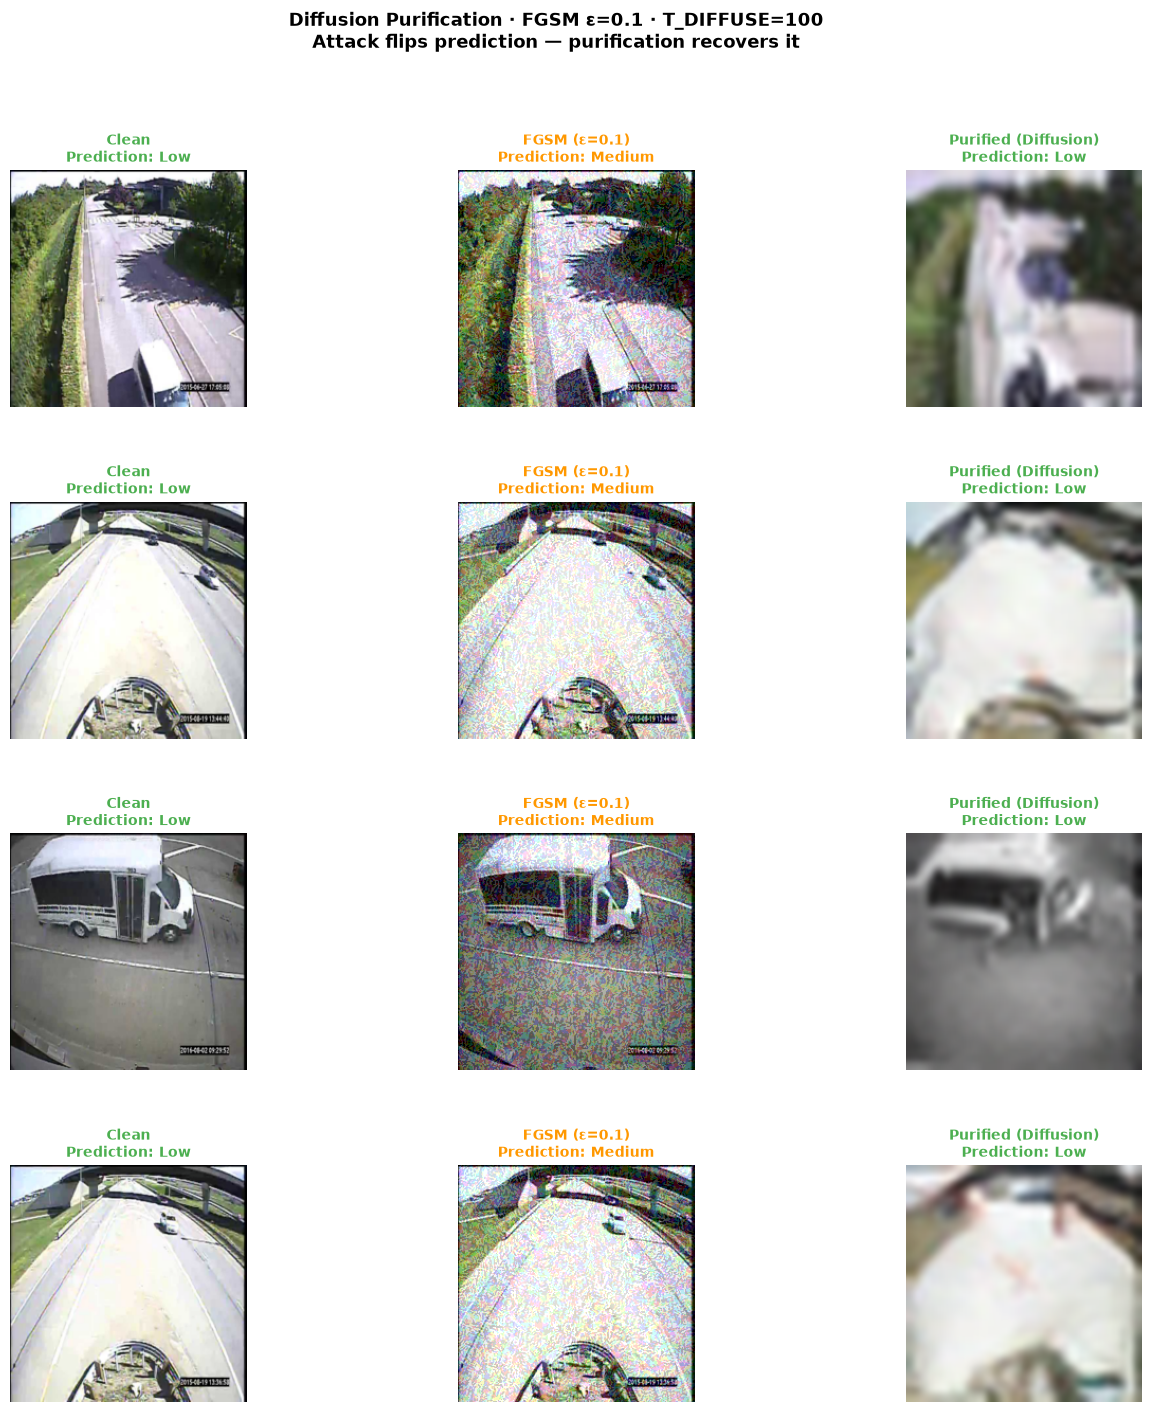

Saved: diffusion_purification_demo.png


In [29]:
# Find 4 examples where: (1) FGSM flipped the prediction AND (2) purification recovered it
story_indices = []
for i in range(N_EVAL):
    attack_flipped   = (adv_preds[i] != clean_preds[i])
    defence_recovered = (defended_preds[i] == clean_preds[i])
    if attack_flipped and defence_recovered:
        story_indices.append(i)
    if len(story_indices) == 4:
        break

if not story_indices:
    print('No "flip + recover" examples found — showing 4 random examples instead.')
    story_indices = list(range(min(4, N_EVAL)))

CLASS_COLORS = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'}

fig = plt.figure(figsize=(16, 4 * len(story_indices)))
gs  = gridspec.GridSpec(len(story_indices), 3, hspace=0.4, wspace=0.3)

for row, i in enumerate(story_indices):
    # ── Reconstruct all three images ──────────────────────────────────────────
    clean_arr = x_clean[i].transpose(1, 2, 0)
    clean_pil_display = Image.fromarray((clean_arr * 255).astype(np.uint8))

    adv_arr = x_adv[i].transpose(1, 2, 0)
    adv_pil_display = Image.fromarray((adv_arr * 255).astype(np.uint8))

    adv_pil_for_purify = Image.fromarray((adv_arr * 255).astype(np.uint8))
    purify_result = purify_and_classify(adv_pil_for_purify)
    purified_pil  = purify_result['purified_image']

    clean_label     = IDX_TO_LABEL[clean_preds[i]]
    attacked_label  = IDX_TO_LABEL[adv_preds[i]]
    defended_label  = IDX_TO_LABEL[defended_preds[i]]

    # ── Plot ──────────────────────────────────────────────────────────────────
    for col, (pil_img, title, label) in enumerate([
        (clean_pil_display,  'Clean',              clean_label),
        (adv_pil_display,    f'FGSM (ε={EPSILON})', attacked_label),
        (purified_pil,       'Purified (Diffusion)', defended_label),
    ]):
        ax = fig.add_subplot(gs[row, col])
        ax.imshow(pil_img.resize((224, 224)))
        ax.axis('off')
        color = CLASS_COLORS.get(label, 'white')
        ax.set_title(f'{title}\nPrediction: {label}',
                     fontsize=10, color=color, fontweight='bold')

fig.suptitle(
    f'Diffusion Purification · FGSM ε={EPSILON} · T_DIFFUSE={T_DIFFUSE}\n'
    f'Attack flips prediction — purification recovers it',
    fontsize=13, fontweight='bold'
)
plt.savefig('diffusion_purification_demo.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: diffusion_purification_demo.png')

---
## 10. Summary

In [30]:
print('TRAFFICGUARD — DIFFUSION PURIFICATION SUMMARY')
print('=' * 58)
print(f'Defence           : Diffusion Purification (DiffPure-style)')
print(f'Reference         : Nie et al., ICML 2022')
print(f'Diffusion model   : {DDPM_MODEL_ID}')
print(f'Purification steps: T_DIFFUSE = {T_DIFFUSE} / {T_TOTAL}')
print(f'Attack evaluated  : FGSM at ε = {EPSILON}')
print(f'Eval images       : {N_EVAL}')
print()
print('Results:')
print(f'  Clean accuracy   : {clean_acc:.2%}')
print(f'  Attacked accuracy: {adv_acc:.2%}')
print(f'  Defended accuracy: {defended_acc:.2%}')
print(f'  ASR (undefended) : {asr:.2%}')
print(f'  Recovery         : {defended_acc - adv_acc:.2%} improvement')
print()
print('Key design decisions:')
print('  - CIFAR-10 DDPM chosen for feasibility on a laptop GPU')
print('  - T_DIFFUSE=100 balances perturbation removal vs semantic preservation')
print('  - Pipeline is model-agnostic: works against any attack, not just FGSM')
print('  - No retraining of ResNet18 required — purely preprocessing defence')
print()
print('Limitations to note in final report:')
print('  - CIFAR-10 DDPM operates at 32×32; upsampling may reduce image fidelity')
print('  - Purification time (~3–5s/image) too slow for real-time traffic systems')
print('  - A production implementation would use an ImageNet-scale diffusion model')
print('  - Adaptive attacks that backprop through the diffusion process can bypass this')
print()
print('Saved outputs:')
for f in ['forward_diffusion_steps.png', 'diffusion_purification_demo.png']:
    exists = '✓' if Path(f).exists() else '✗ not yet generated'
    print(f'  {exists}  {f}')

TRAFFICGUARD — DIFFUSION PURIFICATION SUMMARY
Defence           : Diffusion Purification (DiffPure-style)
Reference         : Nie et al., ICML 2022
Diffusion model   : google/ddpm-cifar10-32
Purification steps: T_DIFFUSE = 100 / 1000
Attack evaluated  : FGSM at ε = 0.1
Eval images       : 50

Results:
  Clean accuracy   : 78.00%
  Attacked accuracy: 46.00%
  Defended accuracy: 54.00%
  ASR (undefended) : 64.00%
  Recovery         : 8.00% improvement

Key design decisions:
  - CIFAR-10 DDPM chosen for feasibility on a laptop GPU
  - T_DIFFUSE=100 balances perturbation removal vs semantic preservation
  - Pipeline is model-agnostic: works against any attack, not just FGSM
  - No retraining of ResNet18 required — purely preprocessing defence

Limitations to note in final report:
  - CIFAR-10 DDPM operates at 32×32; upsampling may reduce image fidelity
  - Purification time (~3–5s/image) too slow for real-time traffic systems
  - A production implementation would use an ImageNet-scale diff